# RAGNAR - online-phase (end-to-end) benchmark analysis

Six completed online runs over the same 499-question NQ subset, each a **one-factor**
change away from `configs/baseline.yaml`. Every number below is rebuilt from the
per-query traces rather than read out of the pre-aggregated block in `run_<job>.json`,
so each headline figure carries a per-query distribution and a bootstrap interval.

| job | config | changed vs baseline |
|---|---|---|
| `119932` | `baseline.yaml`  | - (reference) |
| `120166` | `reranker.yaml`  | cross-encoder `L-6` -> `L-12` |
| `120174` | `chunk.yaml`     | chunker `fixed_word` -> `sentence` |
| `120175` | `embed.yaml`     | embedder `MiniLM-L6` -> `mpnet-base`, metric `cosine` -> `dot` |
| `120695` | `vector_db.yaml` | store `faiss` -> `chroma` |
| `121765` | `generator.yaml` | generator `llama3.2` (3B) -> `llama3.1:8b` |

Arm labels are **not** hard-coded - section 1 diffs each run's resolved config against
the baseline's, so a new arm dropped into `results/runs/` labels itself.

In [1]:
from pathlib import Path
import json, re, string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

MPL = tuple(int(x) for x in matplotlib.__version__.split(".")[:2])
# np.trapz was renamed np.trapezoid in numpy 2.0.
trapz = getattr(np, "trapezoid", None) or np.trapz

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (10, 4),
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})

ROOT    = Path.cwd().parent if Path.cwd().name.lower() == "analysis" else Path.cwd()
RESULTS = ROOT / "results"
FIGS    = ROOT / "Analysis" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

# Same exclusions as the offline notebook: `redundent/` holds runs dropped by hand,
# `old/` is a previous trace schema. Neither may be picked up by accident.
SKIP_DIRS    = {"redundent", "old"}
BASELINE_JOB = "119932"

STAGES      = ["embed", "retrieve", "rerank", "generate"]
STAGE_COLOR = {"embed": "#4C72B0", "retrieve": "#55A868",
               "rerank": "#DD8452", "generate": "#C44E52"}
RNG = np.random.default_rng(0)   # every bootstrap in this notebook draws from here


def find(pattern):
    seen = {}
    for p in sorted(RESULTS.rglob(pattern)):
        if SKIP_DIRS & set(p.relative_to(RESULTS).parts[:-1]):
            continue
        seen.setdefault(p.name, p)
    return [seen[k] for k in sorted(seen)]


# The traces carry UTF-8 prose; on Windows the default cp1252 locale fails on it, so
# every read below names the encoding explicitly.
def read_json(p):
    return json.loads(Path(p).read_text(encoding="utf-8"))


print("root :", ROOT)
for kind, pat in [("run json", "run_*.json"),
                  ("traces  ", "run_*_traces.jsonl"),
                  ("hardware", "hardware_online_*.csv")]:
    print("{}: {:>2} file(s)".format(kind, len(find(pat))))

root : C:\Users\Jespe\Desktop\BACKUP_UNI\ITU\Masters\Thesis RAG Systems\RAGNAR
run json: 12 file(s)
traces  :  6 file(s)
hardware:  7 file(s)


## 1. Load runs, traces and hardware

One row per run in `runs`, one row per **query** in `q` (6 arms x 499 = 2 994 rows).
`q` is the table every later section works from.

In [2]:
def flatten(d, prefix=""):
    out = {}
    for k, v in d.items():
        key = prefix + k
        if isinstance(v, dict):
            out.update(flatten(v, key + "."))
        else:
            out[key] = v
    return out


# index.chroma.* rides along in every config regardless of backend, so it would read as a
# spurious diff on the FAISS arms.
NOISE = ("index.chroma.",)


def resolved_flat(meta):
    f = flatten(meta["config"]["run"]["resolved"])
    return {k: v for k, v in f.items() if not k.startswith(NOISE)}


PRETTY = {
    "online.reranker.model":  "reranker",
    "online.generator.model": "generator",
    "chunker.type":           "chunker",
    "embedder.model":         "embedder",
    "index.database":         "store",
}


def arm_label(job, cfgs, base=BASELINE_JOB):
    # Names what the arm CHANGED, never which job ran it - the SLURM id is scheduler
    # bookkeeping and means nothing to a reader of the figures. It stays in the tables
    # below, which is where you go to trace a number back to its files.
    if job == base:
        return "baseline"
    b, c = cfgs[base], cfgs[job]
    diff = {k: v for k, v in c.items() if b.get(k) != v}
    if not diff:
        return "replicate"
    # embedder.metric moves with embedder.model; name the arm after the primary key.
    for key, name in PRETTY.items():
        if key in diff:
            short = str(diff[key]).split("/")[-1]
            extra = " (metric=" + str(diff["embedder.metric"]) + ")" \
                    if key == "embedder.model" and "embedder.metric" in diff else ""
            return "{}={}{}".format(name, short, extra)
    return ", ".join("{}={}".format(k, v) for k, v in sorted(diff.items()))


run_files = [p for p in find("run_*.json") if not p.name.endswith("_traces_meta.json")]
metas, cfgs = {}, {}
for p in run_files:
    job = re.search(r"run_(\d+)\.json$", p.name).group(1)
    metas[job] = read_json(p)
    cfgs[job]  = resolved_flat(metas[job])

jobs = sorted(metas, key=lambda j: metas[j]["pipeline_start"])
assert BASELINE_JOB in jobs, "baseline run {} not found under results/".format(BASELINE_JOB)

# Two runs of the same arm would otherwise collide on one label and silently merge in
# every groupby below, so a repeat is suffixed by its ordinal - still no job id.
LABEL, seen = {}, {}
for job in jobs:
    lab = arm_label(job, cfgs)
    seen[lab] = seen.get(lab, 0) + 1
    LABEL[job] = lab if seen[lab] == 1 else "{} #{}".format(lab, seen[lab])

rows = []
for job in jobs:
    m = metas[job]
    r = m["config"]["run"]["resolved"]
    rows.append({
        "job_id": job,
        "arm":    LABEL[job],
        "config": Path(m["config"]["run"]["config_source"]).name,
        "n":      m["n_samples"],
        "pipeline_start":  pd.Timestamp(m["pipeline_start"]),
        "pipeline_end":    pd.Timestamp(m["pipeline_end"]),
        "total_elapsed_s": m["total_elapsed_s"],
        "n_failed":  m["failures"]["n_failed"],
        "store":     r["index"]["database"],
        "chunker":   r["chunker"]["type"],
        "embedder":  r["embedder"]["model"],
        "reranker":  r["online"]["reranker"]["model"],
        "generator": r["online"]["generator"]["model"],
        "retriever_top_k": r["online"]["retriever"]["top_k"],
        "rerank_top_k":    r["online"]["reranker"]["top_k"],
        "eval_k":          r["online"]["eval"]["retrieval_k"],
    })
runs = pd.DataFrame(rows)
runs["span_s"] = (runs.pipeline_end - runs.pipeline_start).dt.total_seconds()

ARMS  = runs.set_index("job_id")["arm"].to_dict()
BASE  = "baseline"
ORDER = [BASE] + [ARMS[j] for j in jobs if ARMS[j] != BASE]
COLOR = dict(zip(ORDER, ["#4C72B0", "#DD8452", "#55A868",
                         "#C44E52", "#8172B3", "#937860", "#DA8BC3"]))
EVAL_K = int(runs.eval_k.iloc[0])
assert runs.eval_k.nunique() == 1, "arms disagree on retrieval_k; metrics are not comparable"

runs[["job_id", "arm", "config", "n", "n_failed", "span_s", "total_elapsed_s"]]

,job_id,arm,config,n,n_failed,span_s,total_elapsed_s
0,119932,baseline,baseline.yaml,499,0,363.922,484.85
1,120166,reranker=ms-marco-MiniLM-L-12-v2,reranker.yaml,499,0,374.011,401.12
2,120174,chunker=sentence,chunk.yaml,499,0,750.986,775.84
3,120175,embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),embed.yaml,499,0,364.626,387.52
4,120695,store=chroma,vector_db.yaml,499,0,538.596,562.71
5,121765,generator=llama3.1:8b,generator.yaml,499,0,434.694,467.36


In [3]:
def load_traces(job):
    path = find("run_{}_traces.jsonl".format(job))[0]
    out = []
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            t = json.loads(line)
            g = t["stage_meta"].get("generate") or {}
            row = {
                "job_id": job, "arm": ARMS[job],
                "query_id": t["query_id"], "index": t["index"],
                "query": t["query"], "answer": t.get("answer"),
                "all_answers": t.get("all_answers") or [],
                "ok": t["ok"], "failed_stage": t["failed_stage"],
                "prompt_tokens":     g.get("prompt_tokens"),
                "completion_tokens": g.get("completion_tokens"),
                "tokens_per_sec":    g.get("tokens_per_sec"),
                "ttft_ms":           g.get("ttft_ms"),
                "context_overflow":  g.get("context_overflow"),
                # Relevance is stored as the POSITIONS of the relevant chunks. None means
                # unjudged (no gold answer, or the stage never ran), which is not the same
                # as "judged, nothing relevant" ([]) and must not collapse into a miss.
                "ranks_retrieved": t["retrieved"].get("relevant_ranks"),
                "ranks_reranked":  (t.get("reranked") or {}).get("relevant_ranks"),
                "pool_size":       len(t["retrieved"]["chunk_ids"]),
                "rerank_size":     len((t.get("reranked") or {}).get("chunk_ids") or []),
            }
            row.update({"lat_" + s: t["latency_ms"].get(s) for s in STAGES})
            row["t_start"] = pd.Timestamp(t["wall_time"]["pipeline_start"])
            row["t_end"]   = pd.Timestamp(t["wall_time"]["pipeline_end"])
            out.append(row)
    return pd.DataFrame(out)


q = pd.concat([load_traces(j) for j in jobs], ignore_index=True)
q["arm"] = pd.Categorical(q["arm"], categories=ORDER, ordered=True)

# End-to-end latency is the sum of the four stage timers, not a separate clock. Section 3
# checks what that misses against the wall-clock span of the run.
q["e2e_ms"] = q[["lat_" + s for s in STAGES]].sum(axis=1)

# Every arm ran the same dataset in the same order, so per-query comparisons are PAIRED
# and every bootstrap below resamples query indices rather than rows.
wide = q.pivot_table(index="index", columns="arm", values="e2e_ms", observed=True)
assert wide.notna().all().all(), "arms are not aligned on the same query set"
QIDX = wide.index.to_numpy()
print("queries per arm:", len(QIDX), "| failed rows:", int((~q.ok).sum()),
      "| eval k:", EVAL_K)
q.head(3)

queries per arm: 499 | failed rows: 0 | eval k: 10


,job_id,arm,query_id,index,query,answer,all_answers,ok,failed_stage,prompt_tokens,completion_tokens,tokens_per_sec,ttft_ms,context_overflow,ranks_retrieved,ranks_reranked,pool_size,rerank_size,lat_embed,lat_retrieve,lat_rerank,lat_generate,t_start,t_end,e2e_ms
0,119932,baseline,q0000000,0,what does the academy award for best productio...,The Academy Award for Best Production Design r...,[achievement for art direction in film],True,None,1340,28,175.000000,533.790588,False,[0],[0],100,10,3.812,0.454,39.201,677.219,2026-08-31 20:16:32.685,2026-08-31 20:16:33.406,720.686
1,119932,baseline,q0000001,1,what is animalia,"According to the context provided, Animalia is...",[an illustrated children's book by Graeme Base],True,None,1343,70,194.986072,258.463383,False,[0],[0],100,10,5.693,0.440,45.624,600.811,2026-08-31 20:16:33.409,2026-08-31 20:16:34.061,652.568
2,119932,baseline,q0000002,2,who directed actrius,"According to the context, Actrices was directe...",[Ventura Pons],True,None,1727,18,174.757282,518.247366,False,[1],[0],100,10,3.768,0.450,41.828,607.114,2026-08-31 20:16:34.064,2026-08-31 20:16:34.717,653.160


In [4]:
def load_hw(job):
    hits = find("hardware_online_{}.csv".format(job))
    if not hits:
        return None
    df = pd.read_csv(hits[0])
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # --- monitor.sh DCGM column shift ------------------------------------------------
    # `dcgmi dmon` prints the entity as TWO whitespace fields ("GPU" and "0"), but the awk
    # in monitor.sh indexes from $2 as if it were one. Every dcgmi_* header is therefore
    # off by one field and names the WRONG metric: what the header calls gr_active is
    # power in watts, and what it calls power is memory-copy utilisation. The giveaway is
    # dcgmi_gpu_util_pct, a constant 0.5 in every run - the mean of the two GPU *indices*
    # 0 and 1 on the node. Same correction as the offline notebook; the raw headers are
    # dropped so nothing downstream can read them by mistake.
    shift = {
        "dcgmi_mem_copy_util_pct": "dcgm_gpu_util_pct",   # 203  GPU utilisation %
        "dcgmi_power_w":           "dcgm_mem_copy_pct",   # 204  memory-copy util %
        "dcgmi_gr_active":         "power_w",             # 155  power draw, W
        "dcgmi_sm_active":         "gr_active",           # 1001 graphics engine active
        "dcgmi_pcie_tx_bytes":     "sm_active",           # 1002 SM active
        "dcgmi_pcie_rx_bytes":     "pcie_tx_bytes",       # 1009 PCIe TX
        # 1010 (PCIe RX) falls off the end of the header and is lost.
    }
    if "dcgmi_gr_active" in df.columns:
        df = df.rename(columns=shift).drop(columns=["dcgmi_gpu_util_pct"], errors="ignore")
    df["gpu_mem_GB"] = df["gpu_mem_used_mb"] / 1024
    df["ram_GB"]     = df["ram_used_mb"] / 1024
    df["job_id"], df["arm"] = job, ARMS[job]
    return df.sort_values("timestamp").reset_index(drop=True)


HW = {j: d for j, d in ((j, load_hw(j)) for j in jobs) if d is not None}


def hw_window(job):
    '''Hardware samples inside [pipeline_start, pipeline_end] only.'''
    r = runs.set_index("job_id").loc[job]
    d = HW[job]
    return d[(d.timestamp >= r.pipeline_start) & (d.timestamp <= r.pipeline_end)]


def hw_seconds(job):
    '''
    The in-window samples collapsed to one row per wall-clock second.

    monitor.sh stamps rows to whole seconds but does NOT sample at a fixed rate: it
    emits ~2.5-3 rows per second while the node is busy against ~1 at idle, so several
    rows can share a timestamp and an unweighted mean over raw rows silently
    over-weights the busiest moments. Averaging within each second first restores an
    evenly spaced 1 Hz series, which is what every hardware number in section 9 uses.
    '''
    w = hw_window(job)
    out = w.select_dtypes("number").groupby(w.timestamp).mean()
    out.index.name = "timestamp"
    return out.reset_index()


# Hardware CSVs with no surviving run json - reported, never silently merged in.
orphans = sorted({re.search(r"_(\d+)\.csv$", p.name).group(1)
                  for p in find("hardware_online_*.csv")} - set(jobs))

cov = []
for j in HW:
    d, w = HW[j], hw_window(j)
    span_run = runs.set_index("job_id").loc[j, "span_s"]
    span_csv = (d.timestamp.max() - d.timestamp.min()).total_seconds()
    cov.append({
        "job_id": j, "arm": ARMS[j],
        "rows_total": len(d), "rows_in_window": len(w),
        "in_window_pct": 100 * len(w) / len(d),
        "csv_span_s": span_csv, "run_span_s": span_run,
        "rows_per_s_in": len(w) / span_run,
        "rows_per_s_out": (len(d) - len(w)) / (span_csv - span_run),
        "distinct_s_in": w.timestamp.nunique(),
        "seconds_covered_pct": 100 * w.timestamp.nunique() / span_run,
    })
cov = pd.DataFrame(cov)
print("orphan hardware CSVs (no run json):", orphans or "none")
cov.round(2)

orphan hardware CSVs (no run json):

 ['120121']


,job_id,arm,rows_total,rows_in_window,in_window_pct,csv_span_s,run_span_s,rows_per_s_in,rows_per_s_out,distinct_s_in,seconds_covered_pct
0,119932,baseline,2405,957,39.79,2444.0,363.92,2.63,0.70,349,95.90
1,120166,reranker=ms-marco-MiniLM-L-12-v2,2343,1015,43.32,2342.0,374.01,2.71,0.67,374,100.00
2,120174,chunker=sentence,2708,1352,49.93,2708.0,750.99,1.80,0.69,751,100.00
3,120175,embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),2342,1018,43.47,2341.0,364.63,2.79,0.67,364,99.83
4,120695,store=chroma,2415,1082,44.80,2550.0,538.60,2.01,0.66,530,98.40
5,121765,generator=llama3.1:8b,2478,1122,45.28,2478.0,434.69,2.58,0.66,435,100.07


**Read.** Two things this table exists to catch:

1. The monitor starts well before the pipeline and stops after it, so only ~40-50 % of
   each CSV covers measured queries; the rest is process setup, model load and warm-up.
   Every hardware number below is windowed to `[pipeline_start, pipeline_end]`.
2. **The sampler's rate is not constant.** It emits ~2.5-3 rows/s inside a run against
   ~1 row/s outside it, and its timestamps have whole-second resolution, so rows share
   timestamps and the spacing between them is unrecoverable. A plain `mean()` over raw
   rows is therefore weighted by how fast the sampler happened to be running. Section 9
   averages within each second first (`hw_seconds`) and integrates against wall-clock
   seconds instead.

## 2. End-to-end latency

The headline number for a serving system is the tail, not the mean. `p95`/`p99` are
reported beside the mean because the generator's output length is unbounded below 512
tokens, which makes the distribution long-tailed by construction.

In [5]:
def pctl(s, p):
    return float(np.percentile(s, p))


def boot_ci(values, stat=np.mean, n=5000, alpha=0.05):
    '''Percentile bootstrap over a 1-D sample.'''
    v = np.asarray(values, dtype=float)
    draws = stat(RNG.choice(v, size=(n, v.size), replace=True), axis=1)
    return float(np.percentile(draws, 100 * alpha / 2)), \
           float(np.percentile(draws, 100 * (1 - alpha / 2)))


def paired_boot_ci(delta, n=5000, alpha=0.05):
    '''Percentile bootstrap on a paired per-query difference (arm minus baseline).'''
    d = np.asarray(delta, dtype=float)
    draws = d[RNG.integers(0, d.size, size=(n, d.size))].mean(axis=1)
    return float(np.percentile(draws, 100 * alpha / 2)), \
           float(np.percentile(draws, 100 * (1 - alpha / 2)))


lat = []
for arm, g in q.groupby("arm", observed=True):
    lo, hi = boot_ci(g.e2e_ms)
    lat.append({"arm": arm,
                "mean_ms": g.e2e_ms.mean(), "ci_lo": lo, "ci_hi": hi,
                "median_ms": g.e2e_ms.median(),
                "p95_ms": pctl(g.e2e_ms, 95), "p99_ms": pctl(g.e2e_ms, 99),
                "max_ms": g.e2e_ms.max(),
                "tail_ratio_p99_p50": pctl(g.e2e_ms, 99) / g.e2e_ms.median()})
lat = pd.DataFrame(lat).set_index("arm").loc[ORDER]

# Paired against the baseline: same 499 queries, same order, so the difference is taken
# query by query rather than between two independent means.
base_e2e = wide[BASE].to_numpy()
rel = []
for arm in ORDER:
    d = wide[arm].to_numpy() - base_e2e
    lo, hi = paired_boot_ci(d) if arm != BASE else (0.0, 0.0)
    rel.append({"arm": arm, "delta_ms": d.mean(), "delta_lo": lo, "delta_hi": hi,
                "x_baseline": wide[arm].mean() / base_e2e.mean()})
lat = lat.join(pd.DataFrame(rel).set_index("arm"))
lat.round(2)

,mean_ms,ci_lo,ci_hi,median_ms,p95_ms,p99_ms,max_ms,tail_ratio_p99_p50,delta_ms,delta_lo,delta_hi,x_baseline
arm,,,,,,,,,,,,
baseline,726.31,690.33,764.19,581.94,1641.71,2240.70,2635.44,3.85,0.00,0.00,0.00,1.00
reranker=ms-marco-MiniLM-L-12-v2,746.59,710.40,784.98,593.41,1667.26,2136.89,2381.35,3.60,20.28,-12.73,53.76,1.03
chunker=sentence,1481.78,1444.35,1520.40,1358.32,2467.64,2965.00,3172.77,2.18,755.47,710.79,802.13,2.04
embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),727.72,691.65,763.47,582.95,1592.66,2184.89,2632.33,3.75,1.41,-23.55,25.66,1.00
store=chroma,1076.23,1039.46,1115.70,919.00,2015.13,2299.12,3163.47,2.50,349.92,334.43,366.08,1.48
generator=llama3.1:8b,867.89,838.05,897.52,798.31,1512.60,1861.68,2339.41,2.33,141.58,102.46,180.76,1.19


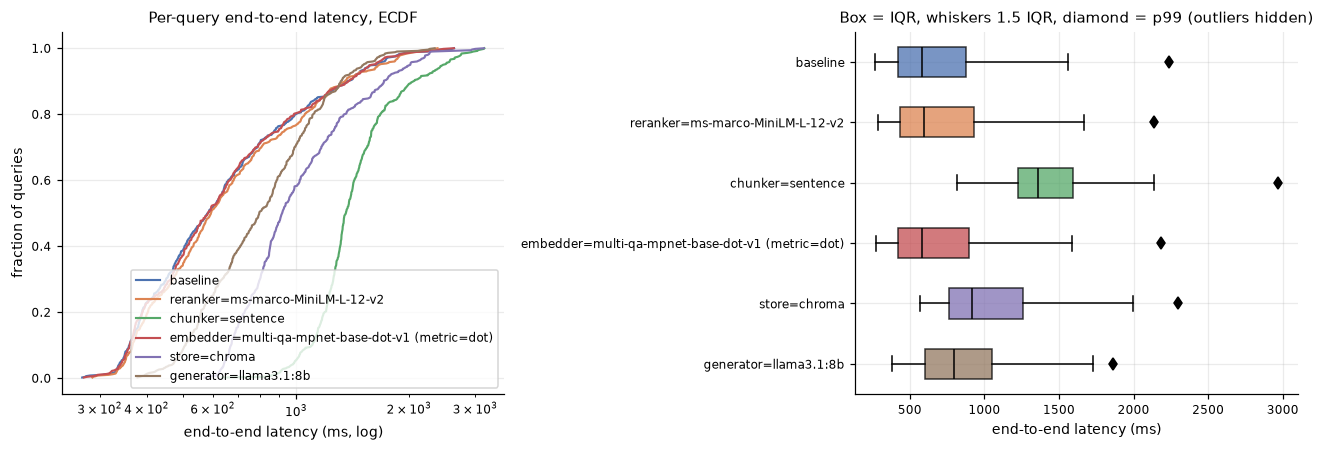

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

# Log x: generate dominates and the retrieve stage is ~0.5 ms, so a linear ECDF hides
# every arm's body in one vertical line.
for arm in ORDER:
    v = np.sort(q.loc[q.arm == arm, "e2e_ms"].to_numpy())
    ax1.plot(v, np.arange(1, v.size + 1) / v.size, lw=1.4,
             color=COLOR[arm], label=arm)
ax1.set_xscale("log")
ax1.set_xlabel("end-to-end latency (ms, log)"); ax1.set_ylabel("fraction of queries")
ax1.set_title("Per-query end-to-end latency, ECDF")
ax1.legend(loc="lower right")

data = [q.loc[q.arm == arm, "e2e_ms"].to_numpy() for arm in ORDER]
# matplotlib renamed `labels` to `tick_labels` in 3.9 and replaced `vert` with
# `orientation` in 3.10; setting the ticks afterwards and branching on the version keeps
# this cell running on either side of both changes.
horiz = {"orientation": "horizontal"} if MPL >= (3, 10) else {"vert": False}
bp = ax2.boxplot(data, showfliers=False, patch_artist=True,
                 medianprops=dict(color="k"), **horiz)
ax2.set_yticks(np.arange(1, len(ORDER) + 1)); ax2.set_yticklabels(ORDER)
for patch, arm in zip(bp["boxes"], ORDER):
    patch.set_facecolor(COLOR[arm]); patch.set_alpha(0.75)
for i, arm in enumerate(ORDER, start=1):
    ax2.plot(pctl(q.loc[q.arm == arm, "e2e_ms"], 99), i, marker="d", ms=6,
             color="k", zorder=5)
ax2.set_xlabel("end-to-end latency (ms)")
ax2.set_title("Box = IQR, whiskers 1.5 IQR, diamond = p99 (outliers hidden)")
ax2.invert_yaxis()
fig.tight_layout(); fig.savefig(FIGS / "online_e2e_latency.png", bbox_inches="tight")
plt.show()

## 3. Where the time goes

Mean latency per stage, and what fraction of end-to-end each stage owns. This is the
decomposition an end-to-end benchmark exists to produce: it says which component a
change can even move.

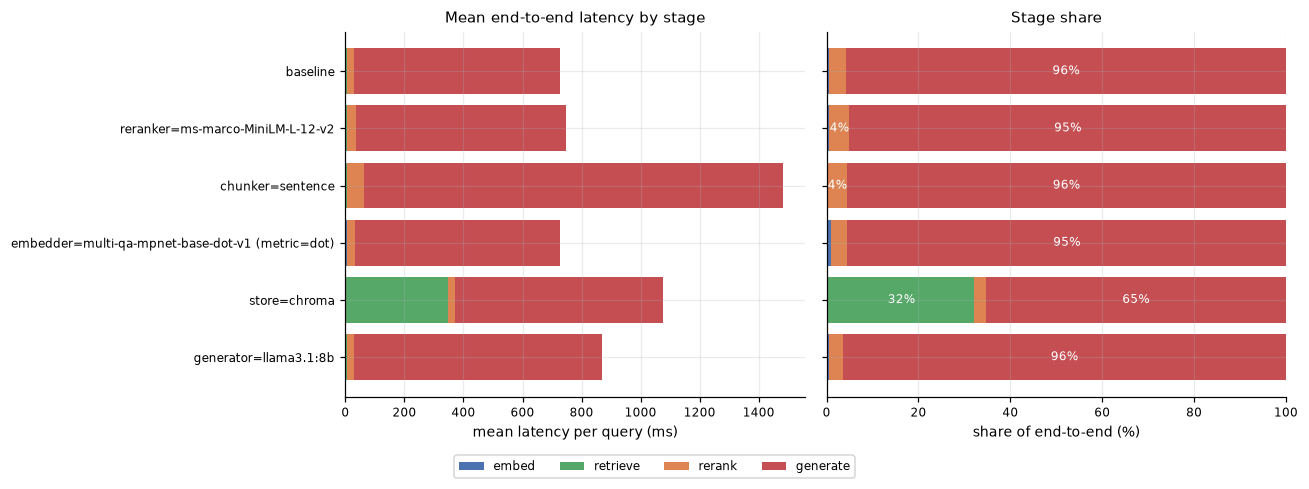

,embed,retrieve,rerank,generate,e2e
arm,,,,,
baseline,3.781,0.460,26.245,695.821,726.308
reranker=ms-marco-MiniLM-L-12-v2,3.753,0.436,32.707,709.694,746.590
chunker=sentence,3.824,0.333,60.432,1417.189,1481.778
embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),6.506,0.490,26.064,694.657,727.716
store=chroma,3.777,342.258,26.548,703.645,1076.228
generator=llama3.1:8b,3.787,0.461,26.143,837.495,867.886


In [7]:
stage_mean = (q.groupby("arm", observed=True)[["lat_" + s for s in STAGES]]
                .mean().loc[ORDER])
stage_mean.columns = STAGES
share = stage_mean.div(stage_mean.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
left = np.zeros(len(ORDER))
ypos = np.arange(len(ORDER))
for s in STAGES:
    ax1.barh(ypos, stage_mean[s], left=left, color=STAGE_COLOR[s], label=s)
    left += stage_mean[s].to_numpy()
ax1.set_yticks(ypos); ax1.set_yticklabels(ORDER); ax1.invert_yaxis()
ax1.set_xlabel("mean latency per query (ms)")
ax1.set_title("Mean end-to-end latency by stage")
# The bars fill the axes, so the stage key goes under the figure rather than on top of
# the baseline row.
fig.legend(*ax1.get_legend_handles_labels(), ncol=4, fontsize=8,
           loc="lower center", bbox_to_anchor=(0.5, -0.06))

left = np.zeros(len(ORDER))
for s in STAGES:
    ax2.barh(ypos, share[s], left=left, color=STAGE_COLOR[s])
    for y, (x0, w) in enumerate(zip(left, share[s])):
        if w > 4:
            ax2.text(x0 + w / 2, y, "{:.0f}%".format(w), ha="center", va="center",
                     fontsize=8, color="w")
    left += share[s].to_numpy()
ax2.set_yticks(ypos); ax2.set_yticklabels([]); ax2.invert_yaxis()
ax2.set_xlim(0, 100); ax2.set_xlabel("share of end-to-end (%)")
ax2.set_title("Stage share")
fig.tight_layout(); fig.savefig(FIGS / "online_stage_decomposition.png", bbox_inches="tight")
plt.show()

stage_mean.assign(e2e=stage_mean.sum(axis=1)).round(3)

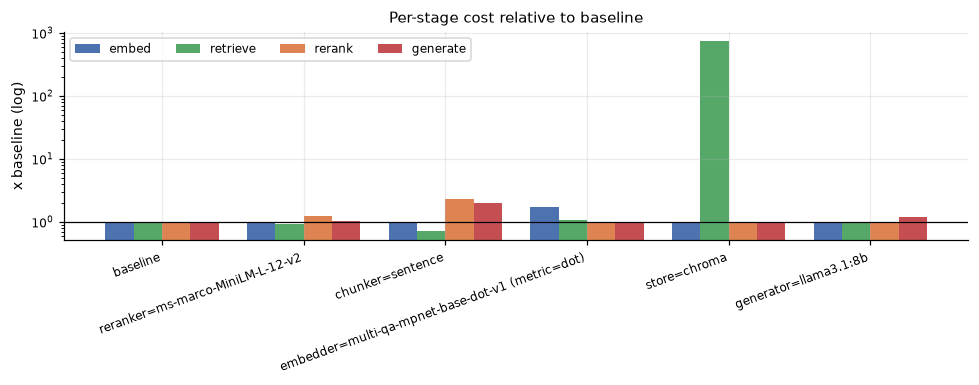

,embed,retrieve,rerank,generate
arm,,,,
baseline,1.000,1.000,1.000,1.000
reranker=ms-marco-MiniLM-L-12-v2,0.993,0.947,1.246,1.020
chunker=sentence,1.012,0.722,2.303,2.037
embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),1.721,1.063,0.993,0.998
store=chroma,0.999,743.319,1.012,1.011
generator=llama3.1:8b,1.002,1.000,0.996,1.204


In [8]:
# Ratio of each arm's stage cost to the baseline's - a one-factor change should move one
# stage and leave the rest alone. Anything else means the arms are not isolated.
ratio = stage_mean.div(stage_mean.loc[BASE], axis=1)
fig, ax = plt.subplots(figsize=(9, 3.6))
w = 0.2
for i, s in enumerate(STAGES):
    ax.bar(np.arange(len(ORDER)) + (i - 1.5) * w, ratio[s], width=w,
           color=STAGE_COLOR[s], label=s)
ax.axhline(1.0, color="k", lw=0.8)
ax.set_yscale("log")
ax.set_xticks(range(len(ORDER)))
ax.set_xticklabels(ORDER, rotation=20, ha="right")
ax.set_ylabel("x baseline (log)")
ax.set_title("Per-stage cost relative to baseline")
ax.legend(ncol=4, fontsize=8)
fig.tight_layout(); fig.savefig(FIGS / "online_stage_ratio.png", bbox_inches="tight")
plt.show()
ratio.round(3)

## 4. Throughput, and what the stage timers miss

Three different totals exist for the same run and they are not interchangeable:

- `sum(stage timers)` - what sections 2-3 measure;
- `pipeline_end - pipeline_start` - wall clock across the measured queries;
- `total_elapsed_s` - the whole job, including warm-up and the offline scoring pass
  (BERTScore, ROUGE) that runs *after* the last query.

Quoting throughput from the wrong one is the easiest mistake in this dataset.

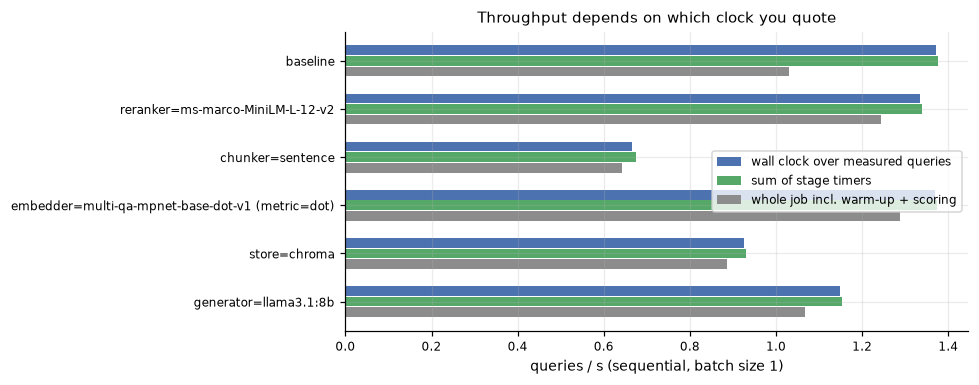

,sum_stages_s,pipeline_span_s,total_elapsed_s,untimed_in_span_s,post_run_s,qps_stage_sum,qps_wallclock,qps_job,s_per_query
arm,,,,,,,,,
baseline,362.427,363.922,484.85,1.495,120.928,1.377,1.371,1.029,0.729
reranker=ms-marco-MiniLM-L-12-v2,372.548,374.011,401.12,1.463,27.109,1.339,1.334,1.244,0.750
chunker=sentence,739.407,750.986,775.84,11.579,24.854,0.675,0.664,0.643,1.505
embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),363.130,364.626,387.52,1.496,22.894,1.374,1.369,1.288,0.731
store=chroma,537.038,538.596,562.71,1.558,24.114,0.929,0.926,0.887,1.079
generator=llama3.1:8b,433.075,434.694,467.36,1.619,32.666,1.152,1.148,1.068,0.871


In [9]:
acct = []
for _, r in runs.iterrows():
    g = q[q.job_id == r.job_id]
    stage_s = g.e2e_ms.sum() / 1000
    acct.append({
        "arm": r.arm,
        "sum_stages_s":    stage_s,
        "pipeline_span_s": r.span_s,
        "total_elapsed_s": r.total_elapsed_s,
        "untimed_in_span_s": r.span_s - stage_s,
        "post_run_s":        r.total_elapsed_s - r.span_s,
        "qps_stage_sum": r.n / stage_s,
        "qps_wallclock": r.n / r.span_s,
        "qps_job":       r.n / r.total_elapsed_s,
        "s_per_query":   r.span_s / r.n,
    })
acct = pd.DataFrame(acct).set_index("arm").loc[ORDER]

fig, ax = plt.subplots(figsize=(9, 3.6))
ypos = np.arange(len(ORDER))
ax.barh(ypos - 0.22, acct.qps_wallclock, height=0.2, color="#4C72B0",
        label="wall clock over measured queries")
ax.barh(ypos,        acct.qps_stage_sum, height=0.2, color="#55A868",
        label="sum of stage timers")
ax.barh(ypos + 0.22, acct.qps_job,       height=0.2, color="#8C8C8C",
        label="whole job incl. warm-up + scoring")
ax.set_yticks(ypos); ax.set_yticklabels(ORDER); ax.invert_yaxis()
ax.set_xlabel("queries / s (sequential, batch size 1)")
ax.set_title("Throughput depends on which clock you quote")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIGS / "online_throughput.png", bbox_inches="tight")
plt.show()
acct.round(3)

## 5. Is the run in steady state?

If latency drifts across the 499 queries - model warm-up, cache fill, thermal throttling,
an Ollama `keep_alive` expiry - then the mean is a mixture and the arms are not being
compared at the same operating point.

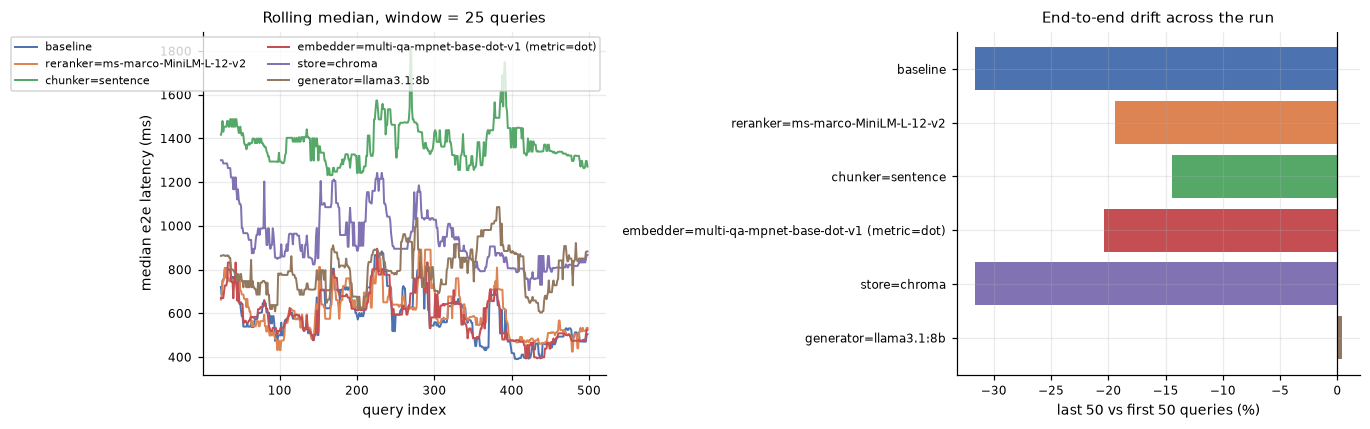

,first50_ms,last50_ms,drift_pct
arm,,,
baseline,869.73,594.71,-31.62
reranker=ms-marco-MiniLM-L-12-v2,859.56,692.69,-19.41
chunker=sentence,1605.20,1373.79,-14.42
embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),826.83,658.27,-20.39
store=chroma,1346.45,920.35,-31.65
generator=llama3.1:8b,926.19,929.51,0.36


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
WIN = 25
for arm in ORDER:
    g = q[q.arm == arm].sort_values("index")
    axes[0].plot(g["index"], g.e2e_ms.rolling(WIN, min_periods=WIN).median(),
                 lw=1.3, color=COLOR[arm], label=arm)
axes[0].set_xlabel("query index"); axes[0].set_ylabel("median e2e latency (ms)")
axes[0].set_title("Rolling median, window = {} queries".format(WIN))
axes[0].legend(fontsize=7, ncol=2)

# First 50 vs last 50 queries: a drift test that does not depend on the window size.
drift = []
for arm in ORDER:
    g = q[q.arm == arm].sort_values("index")
    a, b = g.e2e_ms.iloc[:50], g.e2e_ms.iloc[-50:]
    drift.append({"arm": arm, "first50_ms": a.mean(), "last50_ms": b.mean(),
                  "drift_pct": 100 * (b.mean() - a.mean()) / a.mean()})
drift = pd.DataFrame(drift).set_index("arm").loc[ORDER]
axes[1].barh(np.arange(len(ORDER)), drift.drift_pct,
             color=[COLOR[a] for a in ORDER])
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_yticks(np.arange(len(ORDER))); axes[1].set_yticklabels(ORDER)
axes[1].invert_yaxis(); axes[1].set_xlabel("last 50 vs first 50 queries (%)")
axes[1].set_title("End-to-end drift across the run")
fig.tight_layout(); fig.savefig(FIGS / "online_drift.png", bbox_inches="tight")
plt.show()
drift.round(2)

## 6. Quality, recomputed per query

`run_<job>.json` only stores arm-level means, which cannot carry an interval. The block
below recomputes retrieval quality from the stored `relevant_ranks` and generation
quality from the stored answer text, then **asserts** the recomputation reproduces the
reported aggregates. If an assertion fires, the definitions here and the ones in
`rag_pipeline/metrics.py` have diverged and nothing downstream should be trusted.

In [11]:
def recall_at_k(ranks, k):
    return float(any(r < k for r in ranks))

def precision_at_k(ranks, k):
    return sum(r < k for r in ranks) / k

def rr_at_k(ranks, k):
    hit = [r for r in ranks if r < k]
    return 1.0 / (min(hit) + 1) if hit else 0.0

def ndcg_at_k(ranks, k, ideal_n):
    # Both sides of the rerank comparison are normalised against the ideal ranking of the
    # SHARED candidate pool, matching evaluate.py: normalising the after-list against
    # itself would reward a reranker for discarding relevant chunks.
    dcg  = sum(1 / np.log2(r + 2) for r in ranks if r < k)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(ideal_n, k)))
    return dcg / idcg if idcg else 0.0


K = EVAL_K
pool_n = q.ranks_retrieved.map(lambda r: len(r) if r is not None else 0)

for side in ("retrieved", "reranked"):
    col = "ranks_" + side
    tag = "" if side == "retrieved" else "_rr"
    q["recall" + tag]    = [recall_at_k(r, K) if r is not None else np.nan for r in q[col]]
    q["precision" + tag] = [precision_at_k(r, K) if r is not None else np.nan for r in q[col]]
    q["mrr" + tag]       = [rr_at_k(r, K) if r is not None else np.nan for r in q[col]]
    q["ndcg" + tag]      = [ndcg_at_k(r, K, n) if r is not None else np.nan
                            for r, n in zip(q[col], pool_n)]

# --- generation metrics, same normalisation as rag_pipeline/metrics.py ----------------
_PUNCT = set(string.punctuation)

def normalise_answer(text):
    text = (text or "").lower()
    text = "".join(ch for ch in text if ch not in _PUNCT)
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    return " ".join(text.split())

def answer_accuracy(pred, golds):
    p = normalise_answer(pred)
    if not p:
        return 0.0
    for a in golds:
        a = normalise_answer(a)
        if a and re.search(r"\b" + re.escape(a) + r"\b", p):
            return 1.0
    return 0.0

def token_f1_any(pred, golds):
    pt = normalise_answer(pred).split()
    best = 0.0
    for g in golds:
        gt = normalise_answer(g).split()
        if not pt or not gt:
            best = max(best, float(pt == gt)); continue
        shared = sum((Counter(pt) & Counter(gt)).values())
        if shared:
            pr, rc = shared / len(pt), shared / len(gt)
            best = max(best, 2 * pr * rc / (pr + rc))
    return best

q["answer_accuracy"] = [answer_accuracy(a, g) for a, g in zip(q.answer, q.all_answers)]
q["token_f1"]        = [token_f1_any(a, g) for a, g in zip(q.answer, q.all_answers)]

# --- reconciliation against the reported aggregates ----------------------------------
checks = []
for job in jobs:
    g, s = q[q.job_id == job], metas[job]["stages"]
    for name, mine, theirs in [
        ("recall@k",        g.recall.mean(),          s["retrieval"]["recall_at_k"]),
        ("precision@k",     g.precision.mean(),       s["retrieval"]["precision_at_k"]),
        ("mrr",             g.mrr.mean(),             s["retrieval"]["mrr"]),
        ("ndcg@k",          g.ndcg.mean(),            s["retrieval"]["ndcg_at_k"]),
        ("mrr_after",       g.mrr_rr.mean(),          s["reranking"]["mrr_after"]),
        ("ndcg_after",      g.ndcg_rr.mean(),         s["reranking"]["ndcg_after"]),
        ("recall_after",    g.recall_rr.mean(),       s["reranking"]["recall_after"]),
        # The reranker's own lift, checked against the value the pipeline reports, so the
        # ndcg_rerank_lift column in section 10 is provably the same quantity.
        ("ndcg_delta", g.ndcg_rr.mean() - g.ndcg.mean(), s["reranking"]["ndcg_delta"]),
        ("mrr_delta",  g.mrr_rr.mean() - g.mrr.mean(),   s["reranking"]["mrr_delta"]),
        ("answer_accuracy", g.answer_accuracy.mean(), s["generation"]["avg_answer_accuracy"]),
        ("token_f1",        g.token_f1.mean(),        s["generation"]["avg_token_f1"]),
    ]:
        checks.append({"job_id": job, "metric": name,
                       "recomputed": mine, "reported": theirs,
                       "abs_diff": abs(mine - theirs)})
checks = pd.DataFrame(checks)
worst = checks.abs_diff.max()
assert worst < 1e-9, checks.sort_values("abs_diff", ascending=False).head(10)
print("recomputation matches every reported aggregate; max |diff| = {:.2e}".format(worst))

recomputation matches every reported aggregate; max |diff| = 1.11e-16


In [12]:
# BERTScore and ROUGE-L are only stored as arm-level means (the scorers run in a batch
# pass after the run), so they come from the run json and carry no interval.
QUAL = ["recall", "mrr", "ndcg", "recall_rr", "mrr_rr", "ndcg_rr",
        "answer_accuracy", "token_f1"]
qual = q.groupby("arm", observed=True)[QUAL].mean().loc[ORDER]

JOB_OF = {arm: job for job, arm in ARMS.items()}
for col, key in [("rouge_l", "avg_rouge_l"), ("bert_score", "avg_bert_score")]:
    qual[col] = [metas[JOB_OF[a]]["stages"]["generation"][key] for a in ORDER]
qual.round(4)

,recall,mrr,ndcg,recall_rr,mrr_rr,ndcg_rr,answer_accuracy,token_f1,rouge_l,bert_score
arm,,,,,,,,,,
baseline,0.9539,0.7085,0.7257,1.000,0.9915,0.9481,0.7154,0.2105,0.2185,0.1334
reranker=ms-marco-MiniLM-L-12-v2,0.9539,0.7085,0.7257,1.000,0.9916,0.9483,0.7355,0.2104,0.2178,0.1367
chunker=sentence,0.9980,0.9541,0.9140,1.000,0.9970,0.9449,0.0882,0.0575,0.0636,-0.0400
embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),0.9739,0.7913,0.7940,1.000,0.9915,0.9478,0.7134,0.2126,0.2180,0.1366
store=chroma,0.9499,0.7045,0.7218,0.996,0.9875,0.9442,0.7234,0.2113,0.2200,0.1345
generator=llama3.1:8b,0.9539,0.7085,0.7257,1.000,0.9915,0.9481,0.8597,0.2899,0.3072,0.2042


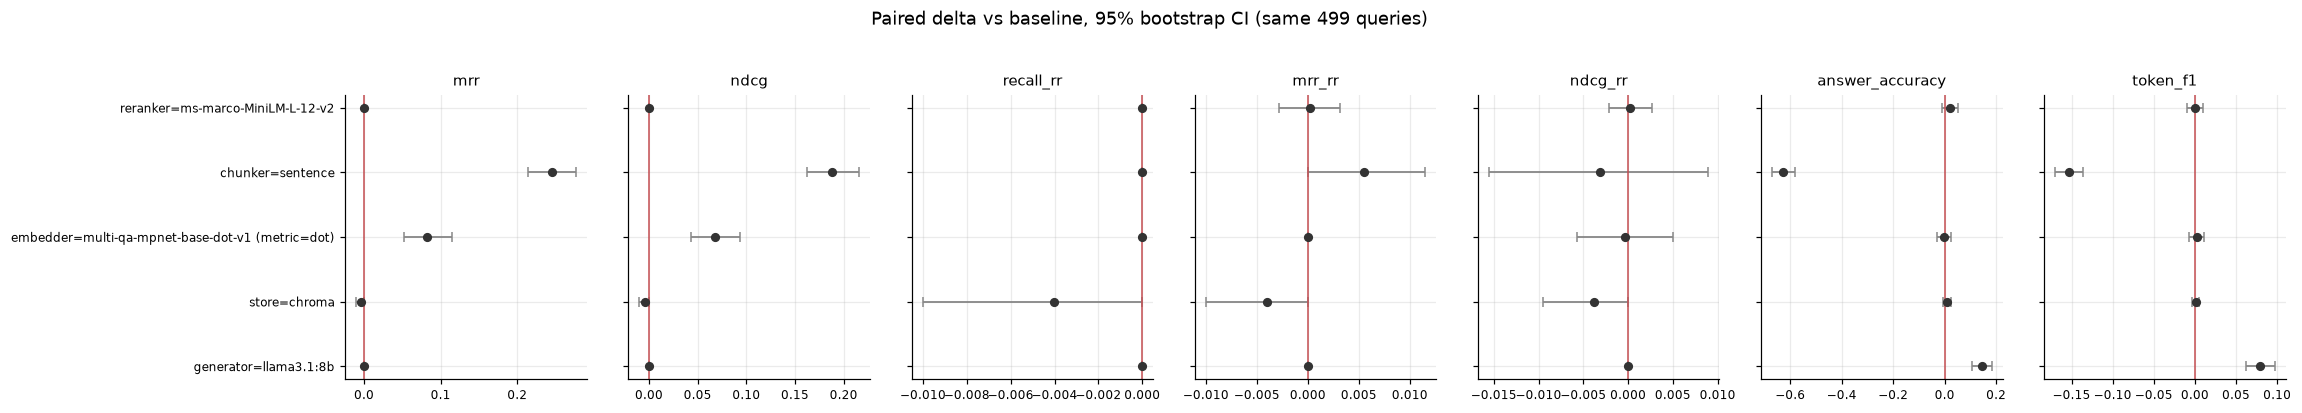

metric,mrr,ndcg,recall_rr,mrr_rr,ndcg_rr,answer_accuracy,token_f1
arm,,,,,,,
reranker=ms-marco-MiniLM-L-12-v2,False,False,False,False,False,False,False
chunker=sentence,True,True,False,False,False,True,True
embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),True,True,False,False,False,False,False
store=chroma,False,False,False,False,True,False,False
generator=llama3.1:8b,False,False,False,False,False,True,True


In [13]:
# Paired deltas vs baseline, with bootstrap intervals. An interval spanning 0 means this
# dataset cannot separate the arm from the baseline on that metric.
PRIMARY = ["mrr", "ndcg", "recall_rr", "mrr_rr", "ndcg_rr", "answer_accuracy", "token_f1"]
deltas = []
for metric in PRIMARY:
    w = q.pivot_table(index="index", columns="arm", values=metric, observed=True)
    for arm in ORDER:
        if arm == BASE:
            continue
        d = (w[arm] - w[BASE]).to_numpy()
        lo, hi = paired_boot_ci(d)
        deltas.append({"metric": metric, "arm": arm, "delta": d.mean(),
                       "lo": lo, "hi": hi,
                       "separates": not (lo <= 0 <= hi)})
deltas = pd.DataFrame(deltas)

fig, axes = plt.subplots(1, len(PRIMARY), figsize=(3.0 * len(PRIMARY), 3.6), sharey=True)
others = [a for a in ORDER if a != BASE]
for ax, metric in zip(axes, PRIMARY):
    sub = deltas[deltas.metric == metric].set_index("arm").loc[others]
    y = np.arange(len(others))
    ax.errorbar(sub.delta, y,
                xerr=[sub.delta - sub.lo, sub.hi - sub.delta],
                fmt="o", ms=5, capsize=3, lw=1.2,
                color="#333333", ecolor="#888888")
    ax.axvline(0, color="#C44E52", lw=1.0)
    ax.set_title(metric); ax.set_yticks(y); ax.set_yticklabels(others)
axes[0].invert_yaxis()
fig.suptitle("Paired delta vs baseline, 95% bootstrap CI (same 499 queries)", y=1.03)
fig.tight_layout(); fig.savefig(FIGS / "online_quality_deltas.png", bbox_inches="tight")
plt.show()

# True where the 95% interval clears 0, i.e. this dataset can tell the arm apart from
# the baseline on that metric. Query sampling only - there is no run-to-run term.
(deltas.pivot_table(index="arm", columns="metric", values="separates")
       .loc[others, PRIMARY].astype(bool))

## 7. Generation internals

Generation owns most of end-to-end, so this is where the latency actually lives.
Time-to-first-token is the queueing/prefill cost; the remainder is decode, which scales
with how many tokens the model chose to emit.

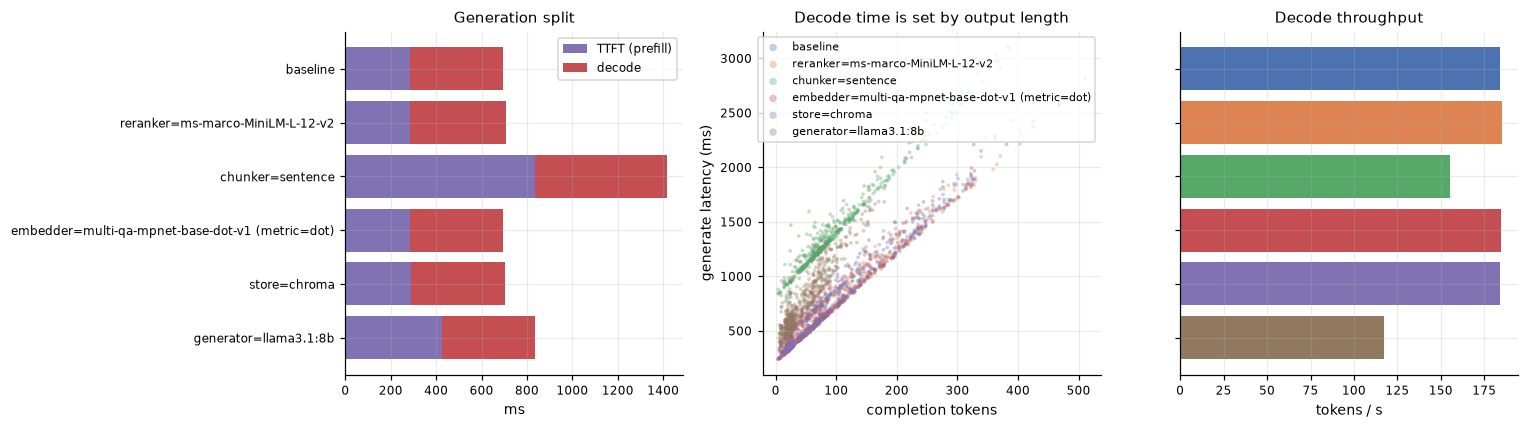

,ttft_ms,decode_ms,generate_ms,prompt_tokens,completion_tokens,tokens_per_sec,ttft_share_pct,overflow_rate,"r(completion_tokens, generate)","r(prompt_tokens, ttft)"
arm,,,,,,,,,,
baseline,284.77,411.05,695.82,1492.08,82.14,184.31,40.93,0.00,0.983,0.011
reranker=ms-marco-MiniLM-L-12-v2,284.62,425.07,709.69,1493.92,85.19,185.16,40.10,0.00,0.983,0.096
chunker=sentence,836.47,580.72,1417.19,8139.87,99.39,155.07,59.02,0.97,0.987,0.476
embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),285.61,409.04,694.66,1488.43,81.95,184.50,41.12,0.00,0.980,-0.043
store=chroma,290.22,413.42,703.65,1492.08,82.28,184.15,41.25,0.00,0.980,0.073
generator=llama3.1:8b,424.19,413.31,837.50,1477.08,53.76,117.23,50.65,0.00,0.927,0.084


In [14]:
gen = q.dropna(subset=["ttft_ms"]).copy()
gen["decode_ms"] = gen.lat_generate - gen.ttft_ms

tbl = gen.groupby("arm", observed=True).agg(
    ttft_ms=("ttft_ms", "mean"),
    decode_ms=("decode_ms", "mean"),
    generate_ms=("lat_generate", "mean"),
    prompt_tokens=("prompt_tokens", "mean"),
    completion_tokens=("completion_tokens", "mean"),
    tokens_per_sec=("tokens_per_sec", "mean"),
).loc[ORDER]
tbl["ttft_share_pct"] = 100 * tbl.ttft_ms / tbl.generate_ms
tbl["overflow_rate"]  = q.groupby("arm", observed=True).context_overflow.mean().loc[ORDER]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ypos = np.arange(len(ORDER))
axes[0].barh(ypos, tbl.ttft_ms, color="#8172B3", label="TTFT (prefill)")
axes[0].barh(ypos, tbl.decode_ms, left=tbl.ttft_ms, color="#C44E52", label="decode")
axes[0].set_yticks(ypos); axes[0].set_yticklabels(ORDER); axes[0].invert_yaxis()
axes[0].set_xlabel("ms"); axes[0].set_title("Generation split"); axes[0].legend(fontsize=8)

for arm in ORDER:
    g = gen[gen.arm == arm]
    axes[1].scatter(g.completion_tokens, g.lat_generate, s=6, alpha=0.35,
                    color=COLOR[arm], label=arm, edgecolors="none")
axes[1].set_xlabel("completion tokens"); axes[1].set_ylabel("generate latency (ms)")
axes[1].set_title("Decode time is set by output length")
axes[1].legend(fontsize=7, markerscale=2)

axes[2].barh(ypos, tbl.tokens_per_sec, color=[COLOR[a] for a in ORDER])
axes[2].set_yticks(ypos); axes[2].set_yticklabels([]); axes[2].invert_yaxis()
axes[2].set_xlabel("tokens / s"); axes[2].set_title("Decode throughput")
fig.tight_layout(); fig.savefig(FIGS / "online_generation.png", bbox_inches="tight")
plt.show()

corr = gen.groupby("arm", observed=True).apply(
    lambda g: pd.Series({
        "r(completion_tokens, generate)": g.completion_tokens.corr(g.lat_generate),
        "r(prompt_tokens, ttft)":         g.prompt_tokens.corr(g.ttft_ms),
    }), include_groups=False).loc[ORDER]
tbl.round(2).join(corr.round(3))

## 8. Cost against quality

The plot an end-to-end benchmark is for: nothing here is free, so each arm is placed by
what it costs per query and what it buys. Error bars are the bootstrap intervals from
sections 2 and 6.

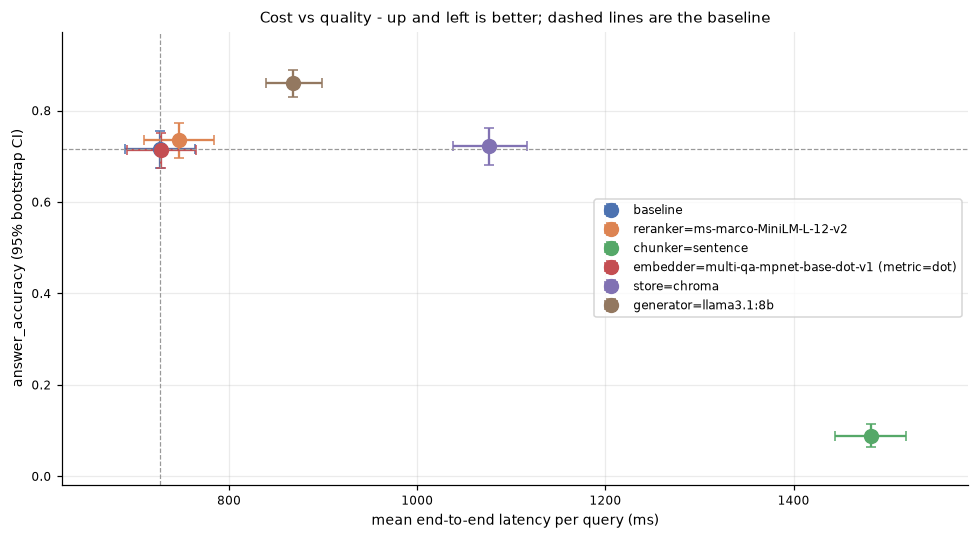

,lat,llo,lhi,qual,qlo,qhi
arm,,,,,,
baseline,726.3076,688.9049,763.6840,0.7154,0.6754,0.7555
reranker=ms-marco-MiniLM-L-12-v2,746.5900,709.9876,783.9973,0.7355,0.6954,0.7735
chunker=sentence,1481.7781,1444.3354,1518.9586,0.0882,0.0641,0.1142
embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),727.7164,691.6441,765.2088,0.7134,0.6733,0.7515
store=chroma,1076.2279,1037.9518,1116.4335,0.7234,0.6814,0.7616
generator=llama3.1:8b,867.8856,838.8300,898.5170,0.8597,0.8297,0.8898


In [15]:
QUALITY_METRIC = "answer_accuracy"   # end-to-end quality: did the answer contain a gold span

pts = []
for arm in ORDER:
    g = q[q.arm == arm]
    llo, lhi = boot_ci(g.e2e_ms)
    qlo, qhi = boot_ci(g[QUALITY_METRIC])
    pts.append({"arm": arm, "lat": g.e2e_ms.mean(), "llo": llo, "lhi": lhi,
                "qual": g[QUALITY_METRIC].mean(), "qlo": qlo, "qhi": qhi})
pts = pd.DataFrame(pts).set_index("arm").loc[ORDER]

fig, ax = plt.subplots(figsize=(9, 5))
for arm, r in pts.iterrows():
    ax.errorbar(r.lat, r.qual,
                xerr=[[r.lat - r.llo], [r.lhi - r.lat]],
                yerr=[[r.qual - r.qlo], [r.qhi - r.qual]],
                fmt="o", ms=9, capsize=3, color=COLOR[arm], label=arm)
b = pts.loc[BASE]
ax.axvline(b.lat, color="0.6", lw=0.8, ls="--")
ax.axhline(b.qual, color="0.6", lw=0.8, ls="--")
ax.set_xlabel("mean end-to-end latency per query (ms)")
ax.set_ylabel(QUALITY_METRIC + " (95% bootstrap CI)")
ax.set_title("Cost vs quality - up and left is better; dashed lines are the baseline")
# Three arms sit almost on top of each other, so the names go in a legend rather than as
# point annotations, which would overlap into an unreadable pile.
ax.legend(fontsize=8, loc="center right")
ax.margins(x=0.08, y=0.10)
fig.tight_layout(); fig.savefig(FIGS / "online_cost_vs_quality.png", bbox_inches="tight")
plt.show()
pts.round(4)

## 9. Hardware during the measured queries

Windowed to `[pipeline_start, pipeline_end]`, DCGM columns corrected in section 1,
collapsed to 1 Hz so the sampler's uneven rate cannot weight the averages. Energy is a
trapezoid integral against wall-clock seconds. Two things to keep in mind:

- the DCGM columns (`power_w`, `dcgm_gpu_util_pct`, `sm_active`) are the mean over the
  **two GPU entities on the node**, of which the job owns one, so power and utilisation
  are diluted by whatever the neighbour was doing - fine for ranking arms measured on the
  same node, not usable as an absolute energy figure;
- `gpu_mem_used_mb` and `gpu_util_pct` come from `nvidia-smi`, which SLURM scopes to the
  job's own device - hence both utilisation columns in the table.

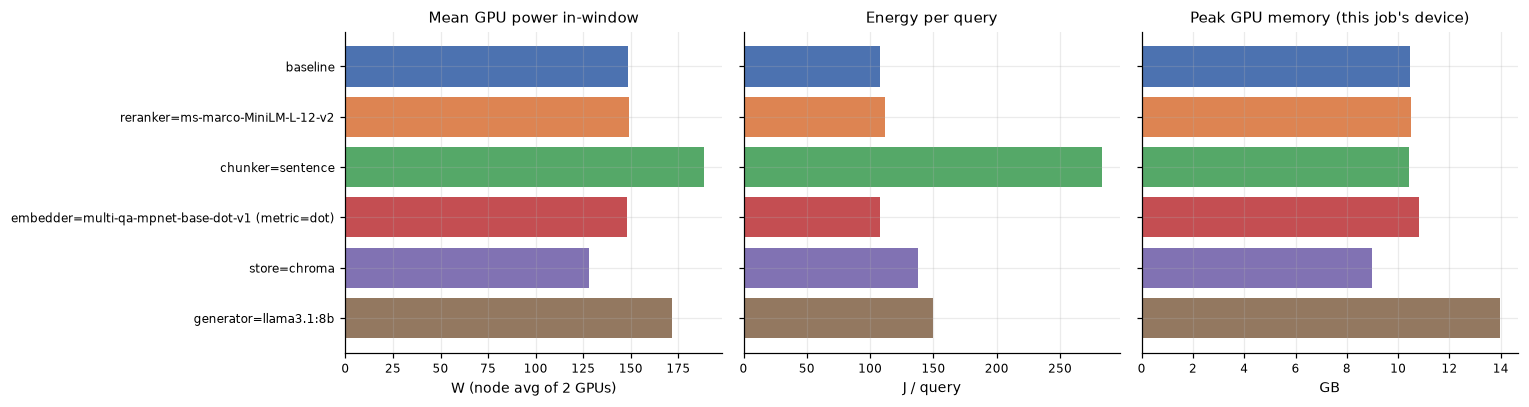

,seconds,power_mean_W,power_p95_W,energy_kJ,J_per_query,dcgm_gpu_util_pct,smi_gpu_util_pct,sm_active,gpu_mem_GB_mean,gpu_mem_GB_peak,cpu_util_pct,ram_GB_peak,disk_util_pct
arm,,,,,,,,,,,,,
baseline,349,148.67,165.86,53.97,108.15,27.88,57.04,0.19,10.42,10.47,1.13,6.30,0.01
reranker=ms-marco-MiniLM-L-12-v2,374,149.01,165.81,55.58,111.38,29.03,58.80,0.19,10.46,10.50,1.13,6.39,0.01
chunker=sentence,751,188.32,212.35,141.24,283.04,37.91,74.21,0.28,10.41,10.42,1.30,6.37,0.01
embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),364,148.09,165.21,53.76,107.73,28.42,57.51,0.18,10.75,10.80,1.13,6.39,0.01
store=chroma,530,127.82,158.22,68.77,137.81,18.67,33.63,0.13,8.94,8.99,1.00,6.30,0.01
generator=llama3.1:8b,435,171.65,193.93,74.49,149.29,29.37,59.34,0.22,13.93,13.97,1.07,6.99,0.01


In [16]:
hw_rows = []
for job in HW:
    s = hw_seconds(job)                      # 1 Hz, evenly spaced - see section 1
    r = runs.set_index("job_id").loc[job]
    t = (s.timestamp - s.timestamp.min()).dt.total_seconds().to_numpy()
    # Trapezoid against wall-clock seconds, so a second the sampler missed is
    # interpolated across rather than dropped from the integral.
    energy_J   = float(trapz(s.power_w.to_numpy(), t))
    covered_s  = float(t[-1] - t[0])
    hw_rows.append({
        "arm": r.arm, "seconds": len(s),
        # Time-weighted, not row-weighted: energy over the span it was integrated on.
        "power_mean_W": energy_J / covered_s,
        "power_p95_W": float(np.percentile(s.power_w, 95)),
        "energy_kJ": energy_J / 1e3,
        "J_per_query": energy_J / r.n,
        "dcgm_gpu_util_pct": s.dcgm_gpu_util_pct.mean(),   # node avg of 2 GPUs
        "smi_gpu_util_pct": s.gpu_util_pct.mean(),         # job-scoped device
        "sm_active": s.sm_active.mean(),
        "gpu_mem_GB_mean": s.gpu_mem_GB.mean(), "gpu_mem_GB_peak": s.gpu_mem_GB.max(),
        "cpu_util_pct": s.cpu_util_pct.mean(),
        "ram_GB_peak": s.ram_GB.max(),
        "disk_util_pct": s.disk_util_pct.mean(),
    })
hw_tbl = pd.DataFrame(hw_rows).set_index("arm")
hw_tbl = hw_tbl.loc[[a for a in ORDER if a in hw_tbl.index]]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
idx = list(hw_tbl.index)
ypos = np.arange(len(idx))
for ax, col, xlabel, title in [
    (axes[0], "power_mean_W", "W (node avg of 2 GPUs)", "Mean GPU power in-window"),
    (axes[1], "J_per_query",  "J / query",              "Energy per query"),
    (axes[2], "gpu_mem_GB_peak", "GB", "Peak GPU memory (this job's device)"),
]:
    ax.barh(ypos, hw_tbl[col], color=[COLOR[a] for a in idx])
    ax.set_yticks(ypos); ax.set_yticklabels(idx if ax is axes[0] else [])
    ax.invert_yaxis(); ax.set_xlabel(xlabel); ax.set_title(title)
fig.tight_layout(); fig.savefig(FIGS / "online_hardware.png", bbox_inches="tight")
plt.show()
hw_tbl.round(2)

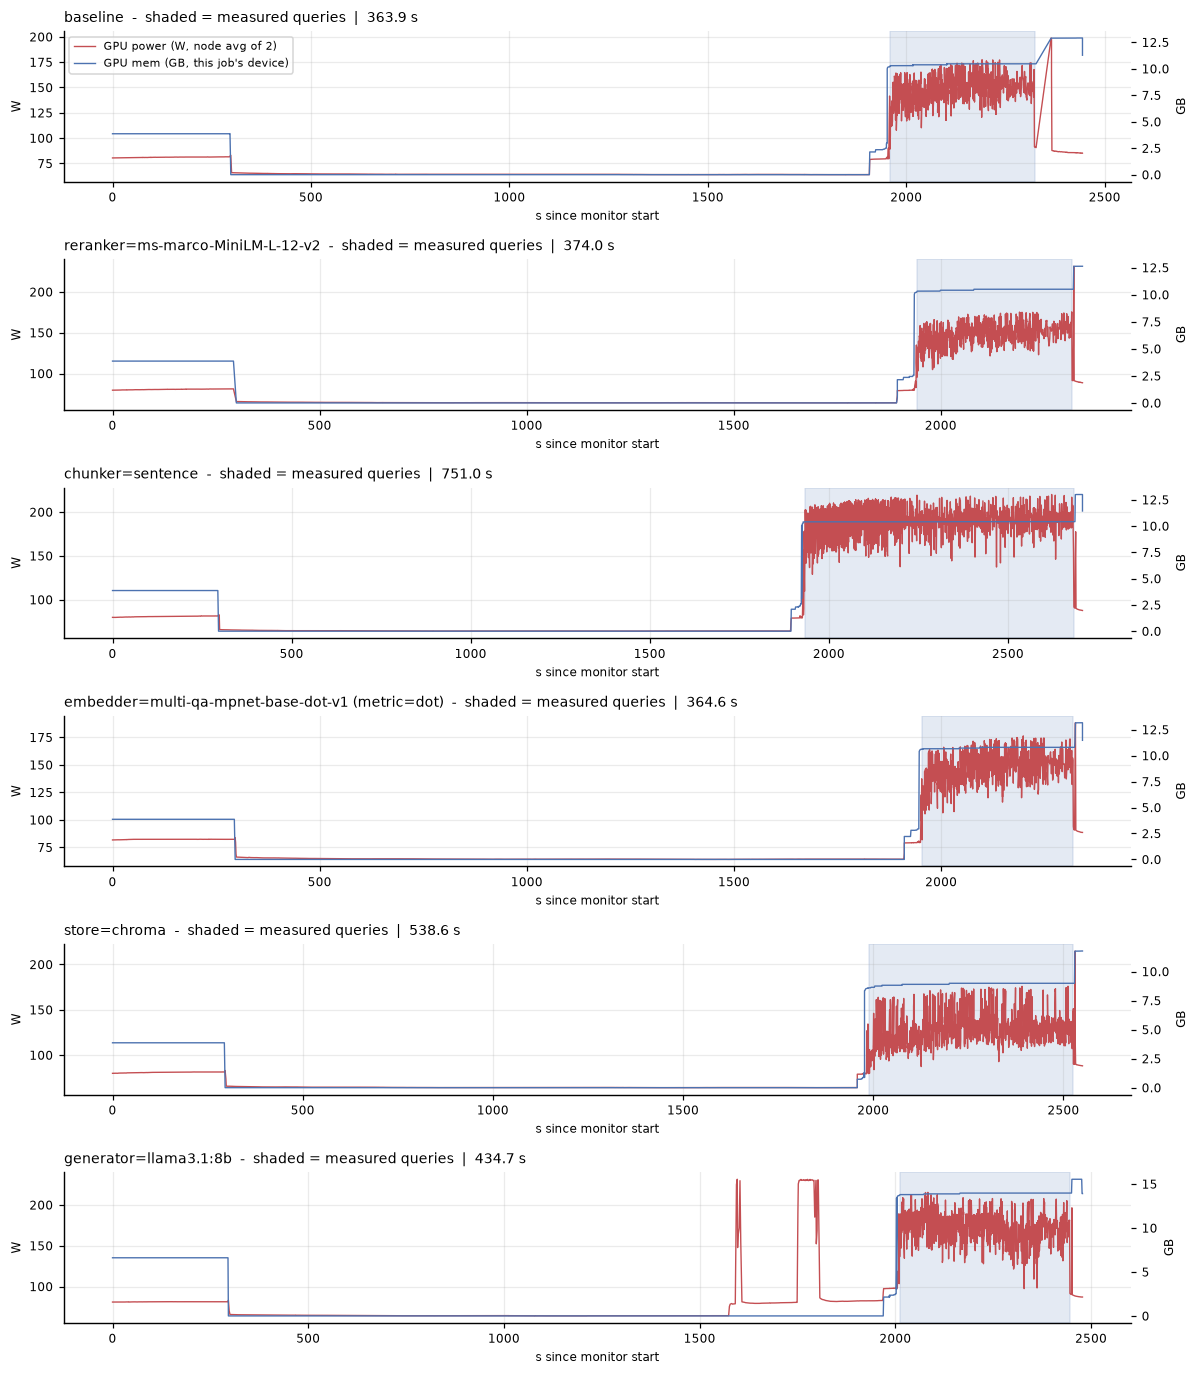

In [17]:
# The trace's own view of the same window: GPU power over time with the measured-query
# span shaded, so setup and warm-up are visibly outside the numbers above.
fig, axes = plt.subplots(len(HW), 1, figsize=(11, 2.1 * len(HW)), sharex=False)
for i, (ax, job) in enumerate(zip(np.atleast_1d(axes), HW)):
    d = HW[job]
    r = runs.set_index("job_id").loc[job]
    t0 = d.timestamp.min()
    x = (d.timestamp - t0).dt.total_seconds()
    ax.plot(x, d.power_w, lw=0.9, color="#C44E52", label="GPU power (W, node avg of 2)")
    ax.axvspan((r.pipeline_start - t0).total_seconds(),
               (r.pipeline_end - t0).total_seconds(),
               color="#4C72B0", alpha=0.15)
    ax2 = ax.twinx(); ax2.grid(False)
    ax2.plot(x, d.gpu_mem_GB, lw=0.9, color="#4C72B0",
             label="GPU mem (GB, this job's device)")
    ax2.set_ylabel("GB", fontsize=8)
    ax.set_ylabel("W", fontsize=8)
    # Same title convention as the offline timeline: arm, what the shading is, then the
    # duration of the window the shading marks - here pipeline_end - pipeline_start, so
    # it is the serving time only, with warm-up and the post-run scoring pass excluded.
    ax.set_title("{}  -  shaded = measured queries  |  {:.1f} s".format(r.arm, r.span_s),
                 fontsize=9, loc="left")
    ax.set_xlabel("s since monitor start", fontsize=8)
    if i == 0:
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, fontsize=7, loc="upper left")
fig.tight_layout(); fig.savefig(FIGS / "online_power_timeline.png", bbox_inches="tight")
plt.show()

**Read.** Every job spends roughly **1 900 s before the first measured query** - imports,
model load, index load, warm-up - against 360-750 s of actual serving, and the GPU is
essentially idle for most of it. Two facts fall out of the picture that no aggregate
shows: the shaded region is the only part any number in this notebook describes, and the
`llama3.1:8b` arm has two power spikes *outside* its window (~1 600 s and ~1 780 s) where
the larger model is pulled and loaded. Its extra GPU memory (14.0 GB peak vs 10.5) is
visible as a step in the blue trace that never comes back down.

## 10. What this dataset supports

Filled in from the numbers this run produced - re-read after a re-run, the assertions in
section 6 guarantee the inputs, not the conclusions.

In [18]:
# Two different "delta nDCG" exist and they answer different questions, so both are here
# and neither is called just "delta":
#   ndcg_rerank_lift - after minus before WITHIN an arm, i.e. what the reranker bought.
#                      Reconciled against stages.reranking.ndcg_delta in section 6.
#   ndcg_rr_vs_base  - this arm's post-rerank nDCG@k minus the baseline's, paired per
#                      query. Section 6 carries its bootstrap interval; here it is the
#                      point estimate only, so read the two together.
ndcg_vs_base = (deltas[deltas.metric == "ndcg_rr"]
                .set_index("arm")["delta"].reindex(ORDER).fillna(0.0))

summary = (lat[["mean_ms", "p95_ms", "x_baseline"]]
           .join(acct[["qps_wallclock"]])
           .join(qual[["mrr", "mrr_rr", "ndcg", "ndcg_rr"]])
           .assign(ndcg_rerank_lift=qual.ndcg_rr - qual.ndcg,
                   ndcg_rr_vs_base=ndcg_vs_base)
           .join(qual[["answer_accuracy", "token_f1", "rouge_l", "bert_score"]])
           .join(tbl[["prompt_tokens", "overflow_rate"]])
           .join(hw_tbl[["power_mean_W", "J_per_query", "gpu_mem_GB_peak"]]))
summary.round(3)

,mean_ms,p95_ms,x_baseline,qps_wallclock,mrr,mrr_rr,ndcg,ndcg_rr,ndcg_rerank_lift,ndcg_rr_vs_base,answer_accuracy,token_f1,rouge_l,bert_score,prompt_tokens,overflow_rate,power_mean_W,J_per_query,gpu_mem_GB_peak
arm,,,,,,,,,,,,,,,,,,,
baseline,726.308,1641.706,1.000,1.371,0.708,0.991,0.726,0.948,0.222,0.000,0.715,0.210,0.219,0.133,1492.078,0.000,148.667,108.149,10.470
reranker=ms-marco-MiniLM-L-12-v2,746.590,1667.260,1.028,1.334,0.708,0.992,0.726,0.948,0.223,0.000,0.735,0.210,0.218,0.137,1493.922,0.000,149.007,111.382,10.505
chunker=sentence,1481.778,2467.642,2.040,0.664,0.954,0.997,0.914,0.945,0.031,-0.003,0.088,0.058,0.064,-0.040,8139.866,0.972,188.319,283.045,10.417
embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),727.716,1592.659,1.002,1.369,0.791,0.991,0.794,0.948,0.154,-0.000,0.713,0.213,0.218,0.137,1488.431,0.000,148.092,107.731,10.796
store=chroma,1076.228,2015.131,1.482,0.926,0.704,0.987,0.722,0.944,0.222,-0.004,0.723,0.211,0.220,0.135,1492.078,0.000,127.822,137.812,8.989
generator=llama3.1:8b,867.886,1512.600,1.195,1.148,0.708,0.991,0.726,0.948,0.222,0.000,0.860,0.290,0.307,0.204,1477.078,0.000,171.646,149.287,13.974


**Reads as measured.**

- **Generation owns end-to-end.** It is ~96 % of mean latency in the baseline; embed and
  retrieve together are under 0.6 %. A change that does not touch the generator, or the
  number of tokens fed to it, cannot move end-to-end latency much - however much it does
  for retrieval quality. Within generation, TTFT is ~41 % and decode tracks output length
  almost perfectly (r ~ 0.98).
- **The store swap is the one exception, and it lands entirely on one stage.** Chroma
  retrieves in ~342 ms against FAISS-`flat`'s ~0.46 ms on the same 45 608 vectors - a
  ~740x stage cost that turns a rounding error into a third of end-to-end. Every other
  stage in that arm is within ~1 % of baseline, which is what a clean one-factor arm
  should look like (section 3).
- **The `sentence` arm is a context-overflow result, not a chunker result.** It improves
  retrieval (MRR 0.71 -> 0.95) and destroys answers (`answer_accuracy` 0.72 -> 0.09),
  because its chunks are long enough that 10 of them average ~8 140 prompt tokens against
  a `num_ctx` of 8 192: **97 % of its queries overflow the context window**. Retrieval
  quality bought nothing because the generator never saw the passage. This is the clearest
  end-to-end finding in the set and it is invisible to any per-stage benchmark.
- **`recall_rr` is a ceilinged metric here** - at or near 1.0 in every arm. Under the DPR
  containment criterion on a *synthetic* question set built from this same corpus, the
  answer string is present by construction. Quote `mrr_rr` / `ndcg_rr`, which still have
  headroom, and note that neither separates any arm from the baseline (section 6).
- **Only two arms move end-to-end quality at all**: the larger generator (+0.14
  `answer_accuracy`) and the `sentence` chunker (-0.63). The reranker and embedder arms
  sit inside the baseline's interval on every quality metric, while the embedder arm does
  measurably improve *retrieval* MRR - quality gained upstream of a saturated reranker
  does not reach the answer.
- **No arm is in steady state.** End-to-end latency falls 14-32 % from the first 50 to the
  last 50 queries in five of six arms (section 5), so each arm's mean is a mixture over a
  changing operating point rather than a steady-state figure.
- Exact match is 0.0 everywhere by construction (the prompt asks for cited prose), which
  is why `answer_accuracy` is the end-to-end quality axis in section 8.

**Not defensible from this dump.**

| claim | blocker | fix |
|---|---|---|
| "arm X is faster/slower than arm Y" for anything under a few percent | one run per arm, so no run-to-run variance term exists - the bootstrap intervals cover query sampling only | 3+ repeats per arm |
| any arm mean as a steady-state latency | 14-32 % downward drift within every run except the 8B arm (section 5) | find the cause (Ollama warm-up? cache fill?), then discard a warm-up prefix rather than 2 queries |
| any absolute watt or joule figure | DCGM averages the two GPUs on the node and the job owns one, so an idle neighbour dilutes it; the numbers are usable for *ranking* arms on the same node, not as absolute energy | log per-GPU DCGM rows, or select the job's GPU by UUID |
| "sentence chunking is worse for RAG" | it is a context-overflow result at this `num_ctx`; the chunker was never tested inside a prompt it fits | re-chunk to ~200 tokens, or raise `num_ctx`, and re-run |
| generator-arm quality deltas as model-size deltas | `llama3.2` (3B) vs `llama3.1:8b` changes parameter count *and* model family at once | hold family fixed, vary size |
| anything about concurrency, batching or saturation | every run is strictly sequential at batch size 1 | a load generator with a target arrival rate |